# Homework 1 solutions

I'm using SymPy -- the symbolic math library for python -- to do the algebra here.  The next 2 cells load SymPy for interactive work and define the variables we are going to use (and treat as math symbols)

In [1]:
from sympy import init_session
init_session(use_latex="mathjax")

IPython console for SymPy 1.14.0 (Python 3.13.7-64-bit) (ground types: gmpy)

These commands were executed:
>>> from sympy import *
>>> x, y, z, t = symbols('x y z t')
>>> k, m, n = symbols('k m n', integer=True)
>>> f, g, h = symbols('f g h', cls=Function)
>>> init_printing()

Documentation can be found at https://docs.sympy.org/1.14.0/



## 1. stellar model

We have a star with a mass profile:

$$M(r) = 4\pi R_\star^3 \beta \left [ - \frac{r \cos(\pi r / R_\star)}{\pi R_\star} + \frac{\sin(\pi r/R_\star)}{\pi^2} \right ]$$

we want to find the density and its properties from this.

Let's define some symbolic variables

In [2]:
rho = symbols("rho", cls=Function)
rhoc = symbols("rho_c")
Mstar, Rstar = symbols(r"M_\star R_\star")
r = symbols("r")
xi = symbols("xi'")
beta = symbols("beta")

Now let's compute $M(r)$

In [3]:
M = 4 * pi * Rstar**3 * beta * (-r * cos(pi * r / Rstar) / pi / Rstar +
                                sin(pi * r / Rstar) / pi**2)
M

               ⎛   ⎛  π⋅r  ⎞        ⎛  π⋅r  ⎞⎞
               ⎜sin⎜───────⎟   r⋅cos⎜───────⎟⎟
           3   ⎜   ⎝R_\star⎠        ⎝R_\star⎠⎟
4⋅π⋅R_\star ⋅β⋅⎜──────────── - ──────────────⎟
               ⎜      2          π⋅R_\star   ⎟
               ⎝     π                       ⎠

**a**. Find the density profile

The density profile that gives this comes from the continuity equation:

$$\rho = \frac{1}{4\pi r^2} \frac{dM}{dr}$$

which we can compute easily

In [4]:
rho = M.diff(r) / (4 * pi * r**2)
rho

             ⎛  π⋅r  ⎞
R_\star⋅β⋅sin⎜───────⎟
             ⎝R_\star⎠
──────────────────────
          r           

**b**. Express $\beta$ in terms of central density, $\rho_c$

If we just evaluate this at $r = 0$, we run into trouble:

In [5]:
rho.subs(r, 0)

nan

Instead we need to take a limit (using L'Hôpital's rule)

In [6]:
rho_c_val = rho.limit(r, 0)
rho_c_val

π⋅β

This shows us that $\beta = \rho_c / \pi$.  We can rewrite the density in terms of this.

In [7]:
rho = rho.subs(beta, rhoc / pi)
rho

               ⎛  π⋅r  ⎞
R_\star⋅ρ_c⋅sin⎜───────⎟
               ⎝R_\star⎠
────────────────────────
          π⋅r           

We can plot this now (we need to make it dimensionless, so we'll plot in terms of $\xi = r / R_\star$)

<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in scalar divide
  return sin(pi*Dummy_35)/(pi*Dummy_35)


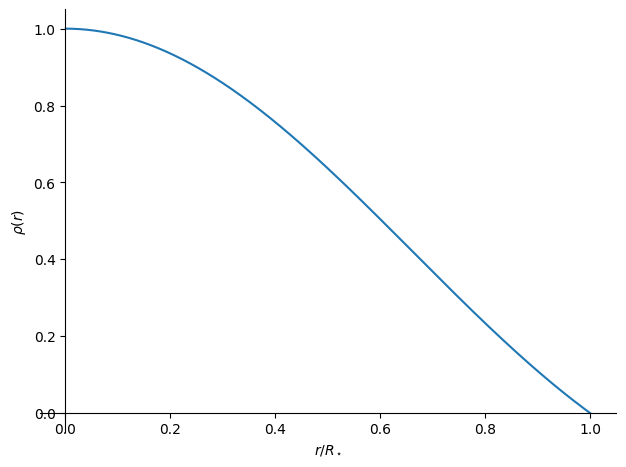

In [8]:
z = (rho/rhoc).subs(r, xi*Rstar)
plot(z, (xi, 0, 1), xlabel=r"$r/R_\star$", ylabel=r"$\rho(r)$")

**c**. ratio of central to average

The average density is just the total mass divided by the volume of the star.

```{caution}
You might think that you can compute the average density simply as:

$$\bar{\rho} = \frac{1}{R_\star} \int_0^{R_\star} \rho(r) dr$$

but this does not have the correct volume weighting for a spherically symmetric model.
```

Let's rewrite the mass function in terms of $\rho_c$ first:

In [9]:
M = M.subs(beta, rhoc / pi)
M

               ⎛   ⎛  π⋅r  ⎞        ⎛  π⋅r  ⎞⎞
               ⎜sin⎜───────⎟   r⋅cos⎜───────⎟⎟
         3     ⎜   ⎝R_\star⎠        ⎝R_\star⎠⎟
4⋅R_\star ⋅ρ_c⋅⎜──────────── - ──────────────⎟
               ⎜      2          π⋅R_\star   ⎟
               ⎝     π                       ⎠

Now we need the total mass:

In [10]:
Mstar = M.subs(r, Rstar)
Mstar

         3    
4⋅R_\star ⋅ρ_c
──────────────
      π       

and now we compute

$$\bar{\rho} = \frac{M_\star}{(4/3) \pi R_\star^3}$$

In [11]:
rhobar = symbols(r"\bar{\rho}")
rhobar = Mstar / (Rational(4,3)*pi*Rstar**3)
rhobar

3⋅ρ_c
─────
  2  
 π   

This shows that

$$\frac{\rho_c}{\bar{\rho}} = \frac{\pi^2}{3}$$

```{note}
This mass / density profile represents a polytrope model--the $n=1$ solution to the Lane-Emden equation.  This is a topic we will study shortly.
```

## 2. Terrestrial HSE

We want to consider HSE for the ocean.  We are going to assume that $\rho = constant$ and $g = constant$.  Then our equation of HSE is simply:

$$\frac{dP}{dr} = - \rho |g|$$

We can integrate this easily.  We'll take the surface of the ocean to be $z=0$ and the depth where we are evaluating the pressure to be $-z$.

$$\int_{-z}^0 dP = -\int_{-z}^0 \rho |g| dz$$

if we take $P(0) = P_0$ (which is 1 atm of pressure from the atmosphere), then we get:

$$P(-z) = P_0 + \rho |g| z$$

(where $z > 0$ is the depth below the surface).

We can put in numbers:

In [12]:
import unyt

g = 981 * unyt.cm / unyt.s**2
atm = (1 * unyt.atm).in_cgs()
Pz = (90 * unyt.bar).in_cgs()
rho = 1 * unyt.g / unyt.cm**3

In [13]:
atm

unyt_quantity(1013250., 'dyn/cm**2')

In [14]:
z = (Pz - atm) / (rho * g)
z.to("km")

unyt_quantity(0.90710245, 'km')

We see that the depth required is almost 1 km!

## 3. Virial theorem

We have a close binary system of masses $M_1$ and $M_2$ in circular orbits.  

The initial velocities are $v_1$ and $v_2$, and the center of mass condition requires:

$$M_1 v_1 = M_2 v_2$$

The initial energy is:

$$E_i = \frac{1}{2}M_1 v_1^2 + \frac{1}{2} M_2 v_2^2 - \frac{GM_1 M_2}{a}$$

where $a$ is the separation.

Now the Virial theorem holds initially, so:

$$2K = -\Omega$$

and we have

$$M_1 v_1^2 + M_2 v_2^2 = \frac{GM_1M_2}{a}$$

Using the center of mass condition to eliminate $v_2$ and solving for $v_1$, we have:

$$v_1^2 = \frac{GM_2}{a} \left( 1 + \frac{M_1}{M_2} \right )^{-1}$$

Now we imagine that $M_1$ rapidly losses mass in a spherically symmetric way (e.g., a supernova), and that the remnant of star 1, with mass $M_\mathrm{rem}$ continues to have the same orbital velocity, $v_1$, after the mass loss.

The final energy is then just the initial energy with $M_1$ replaced by $M_2$:

$$E_f = \frac{1}{2}M_\mathrm{rem} v_1^2 + \frac{1}{2} M_2 v_2^2 - \frac{GM_\mathrm{rem}M_2}{a}$$

now we can add and subtract $\frac{1}{2}M_1 v_1^2$ from this, and group things:

$$E_f = \frac{1}{2}M_\mathrm{rem} v_1^2 - \frac{1}{2}M_1 v_1^2 +
   \underbrace{\frac{1}{2}M_1 v_1^2 + \frac{1}{2} M_2 v_2^2}_{= \frac{GM_1 M_2}{a} \mbox{~by Virial}} - \frac{GM_\mathrm{rem}M_2}{a}$$

and we have

$$E_f = \frac{1}{2} (M_\mathrm{rem} - M_1) v_1^2 + \frac{1}{2} \frac{GM_1 M_2}{a} - \frac{GM_\mathrm{rem} M_2}{a}$$

Now using our expression for $v_1$, we have:

$$E_f = \frac{GM_2}{a} \left [\frac{1}{2} (M_\mathrm{rem} - M_1) \left ( 1 + \frac{M_1}{M_2} \right )^{-1} + \frac{M_1}{2} - M_\mathrm{rem} \right ]$$ 

To be bound, we requre $E_f < 0$, which means:

$$\frac{1}{2} (M_\mathrm{rem} - M_1) \left ( 1 + \frac{M_1}{M_2} \right )^{-1} + \frac{M_1}{2} - M_\mathrm{rem} < 0$$

rearranging, we find:

$$\frac{M_\mathrm{rem}}{M_1 + M_2} < \frac{1}{(1 + M_2/M_1)(2 + M_2 / M_1)}$$

In the limit $M_2 \ll M_1$, this is

$$\frac{M_\mathrm{rem}}{M_1 + M_2} \rightarrow \frac{1}{2}$$

```{note}
This says that if the explosion ejects more than 1/2 of the mass of the system, then we are unbound.  Later we will see that binary systems can survive the explosion!
```

## 4. Central pressure limit

We want to find a lower bound to the central pressure of a star.  We already did this one way in class, when we considered the constant-density model.

Now let's start with HSE:

$$\frac{dP}{dM} = - \frac{GM}{4\pi r^4}$$

and integrate from the center to the surface:

$$\int_0^R dP = - \int_0^R \frac{GM}{4\pi r^4} dM$$

for the integral on the left, we use the boundary condition that the pressure vanishes at the surface, $P(R) = 0$, which gives:

$$P_c = \int_0^R \frac{GM}{4 \pi r^4} dM$$

we can't do this integral, since $r = r(M)$, and we don't know that relationship.  However, we know that everywhere in the star, $r \le R$, and since this term appears in the denominator, if we take $r = R$, then we are underestimating the pressure, so that means:

$$P_c \ge \frac{GM}{4 \pi R^4} \int_0^R dM = \frac{GM^2}{4\pi R^4}$$

This is smaller than the limit we found in class.

## 5. Wien's law

**a**. We want to find Wien's law from the Planck spectrum.  We'll work in terms of wavelength and start with

$$I = \frac{2 h c^2 / \lambda^5}{e^{hc/\lambda k T} - 1}$$

and make the substitution $x = \lambda k T/ hc$

This gives:

$$I = 2 h c^2 \left (\frac{kT}{hc} \right )^5 \frac{x^{-5}}{e^{1/x} - 1}$$

Let's write a function to give the dimensionless part of this

In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def I(x):
    return x**-5 / np.expm1(1/x)

Now let's plot it, to get a sense of that it looks like:

/tmp/ipykernel_3428979/638481622.py:2: RuntimeWarning: divide by zero encountered in power
  return x**-5 / np.expm1(1/x)
/tmp/ipykernel_3428979/638481622.py:2: RuntimeWarning: divide by zero encountered in divide
  return x**-5 / np.expm1(1/x)
/tmp/ipykernel_3428979/638481622.py:2: RuntimeWarning: invalid value encountered in divide
  return x**-5 / np.expm1(1/x)


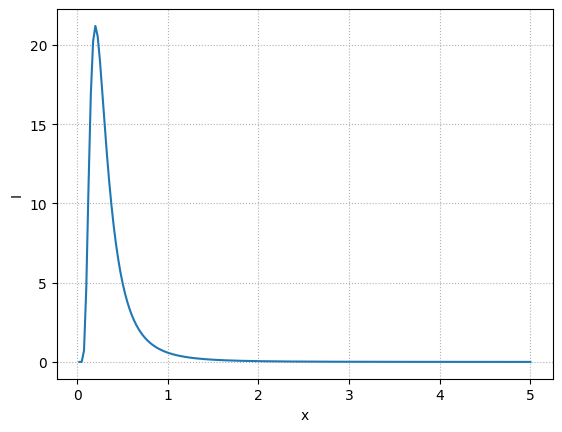

In [17]:
fig, ax = plt.subplots()
xs = np.linspace(0, 5, 200)
ax.plot(xs, I(xs))
ax.set_xlabel("x")
ax.set_ylabel("I")
ax.grid(ls=":")

Notice that the peak is near $x \sim 0.25$

Now we differentiate $I(x)$ and set it equal to zero, giving:

$$\frac{x^{-5}}{e^{1/x} - 1} \left ( -\frac{5}{x} + \frac{1}{e^{1/x} - 1} \frac{e^{1/x}}{x^2} \right )$$

We can use any root finding method, like SciPy's Brent's method, to find the root.  From the plot above, we expect it to be between $[0, 1]$, but also, $x=0$ will do bad things, so we'll start our root search a bit away from that.

In [18]:
def Iprime(x):
    return x**-5 / np.expm1(1/x) * (-5.0 / x + 1.0 / np.expm1(1/x) * np.exp(1/x) / x**2)

In [19]:
from scipy import optimize

In [20]:
r = optimize.brentq(Iprime, 0.01, 1)
r

0.20140523527264226

So the root is $x = 0.201$ or $1/x = 4.965$.

Now we add back in the units:

$$\lambda T = \frac{hc}{k} x$$

In [21]:
k = 1.38e-16  # erg /K
c = 3e10  # cm/s
h = 6.63e-27  # erg s

In [22]:
print(h*c/k * r)

0.29028624127339525


This shows that 

$$\lambda T = 0.29 ~\mathrm{cm~K}$$

**b**. Now we want to estimate the Earth's temperature.

At the Earth, the solar flux is:

$$f = \frac{L_\odot}{4 \pi d^2}$$

where $d = 1~\mathrm{AU}$ is the Earth-Sun distance.

The Earth presents a circular cross section, so the power absorbed by the Earth is:

$$P_\mathrm{abs} = \epsilon \pi R_\oplus^2 f$$

where $\epsilon$ is the efficiency (so $1-\epsilon$ is the albedo).

Now, we assume that the Earth emits over its entire surface as a blackbody, so its emission is:

$$P_\mathrm{emit} = 4 \pi R_\oplus \sigma T_\oplus^4$$

As a blackbody, emission equals absorption, so:

$$4\pi R_\oplus \sigma T_\oplus^4 = \epsilon \pi R_\oplus^2 f$$

or 

$$T_\odot = \left ( \frac{\epsilon f}{4\sigma} \right )^{1/4}$$

Let's put in numbers:

In [23]:
d = 1.5e13  # cm
sigma = 5.67e-5  # erg / s / cm^2 / K^4
L_sun = 3.9e33  # erg / s
eps = 0.6

In [24]:
f = L_sun / (4 * np.pi * d**2)
T_earth = (eps * f / (4 * sigma))**0.25
T_earth

245.77918867094036

```{note}
This is cold.  The blackbody temperature of Earth is below freezing.  But we neglected the atmosphere and the greenhouse effect that raises the Earth's surface temperature to above the freezing point.
```